# EDA — E-Commerce Fraud Transactions (`Fraud_Data.csv`)

**Project:** Improved Detection of Fraud Cases — Adey Innovations Inc.  
**Task:** Task 1 — Data Analysis and Preprocessing  
**Dataset:** `Fraud_Data.csv` + `IpAddress_to_Country.csv`

---

## Objectives

1. Understand the structure and quality of the e-commerce transaction dataset.
2. Identify and handle missing values, duplicates, and incorrect data types.
3. Explore univariate distributions and bivariate relationships with the fraud label.
4. Quantify and visualize the class imbalance.
5. Enrich transactions with geolocation data via IP-to-country range lookup.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Imports & Configuration |
| 2 | Load Data |
| 3 | Data Cleaning |
| 4 | Exploratory Data Analysis |
| 5 | Class Imbalance Analysis |
| 6 | Geolocation Integration |
| 7 | Save Cleaned Data |

## 1. Imports & Configuration

Set up all required libraries, configure logging, plot styling, and define 
directory paths used throughout this notebook.

In [18]:
import sys
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Logging configuration
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s'
)
logger = logging.getLogger(__name__)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Paths
RAW_DIR = '../data/raw/'
PROCESSED_DIR = '../data/processed/'

logger.info('Libraries loaded successfully.')

2026-06-07 19:52:55,733 — INFO — Libraries loaded successfully.


## 2. Load Data

Load `Fraud_Data.csv` and `IpAddress_to_Country.csv` from the raw data directory.
File loading is wrapped in error handling to catch missing files early and surface
a clear message before any downstream steps run.

In [19]:
try:
    fraud_df = pd.read_csv(RAW_DIR + 'Fraud_Data.csv')
    ip_df = pd.read_csv(RAW_DIR + 'IpAddress_to_Country.csv')
    logger.info(f'Fraud_Data loaded: {fraud_df.shape}')
    logger.info(f'IpAddress_to_Country loaded: {ip_df.shape}')
except FileNotFoundError as e:
    logger.error(f'Dataset not found: {e}')
    logger.error('Place raw CSVs in data/raw/ before running this notebook.')
    raise
except Exception as e:
    logger.error(f'Unexpected error loading data: {e}')
    raise

print('--- Fraud_Data: first 5 rows ---')
display(fraud_df.head())
print('\n--- IpAddress_to_Country: first 5 rows ---')
display(ip_df.head())

2026-06-07 19:53:00,827 — INFO — Fraud_Data loaded: (151112, 11)
2026-06-07 19:53:00,828 — INFO — IpAddress_to_Country loaded: (138846, 3)


--- Fraud_Data: first 5 rows ---


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0



--- IpAddress_to_Country: first 5 rows ---


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


## 3. Data Cleaning

Steps performed in this section:

- **3.1 Basic Inspection** — review shape, dtypes, and memory usage to understand
  the dataset before making any changes.
- **3.2 Missing Values** — detect columns with nulls, report count and percentage,
  and drop rows where the target variable (`class`) is missing since those records
  cannot be used for supervised learning.
- **3.3 Duplicates** — identify and remove exact duplicate rows to prevent data
  leakage and inflated evaluation metrics.
- **3.4 Fix Data Types** — parse `signup_time` and `purchase_time` as proper
  datetime objects (they arrive as strings) and cast the target to integer.
  ## 3.5 Encoding and Scaling

Apply one-hot encoding to categorical features and StandardScaler to numerical
features. Both transformers are fitted on the training split only to prevent
data leakage — the test set is transformed using the already-fitted objects.

## 3.6 Handling Class Imbalance — SMOTE

The dataset has a ~10:1 legitimate-to-fraud ratio. We apply SMOTE (Synthetic
Minority Oversampling Technique) exclusively on the training split to generate
synthetic fraud examples and balance the classes.

**Why SMOTE over undersampling?**
Undersampling would discard ~122,000 legitimate records, throwing away real
behavioral signal. SMOTE instead synthesizes new minority-class samples by
interpolating between existing fraud examples, preserving all majority-class
data while giving the model enough fraud examples to learn from.

SMOTE is never applied to the test set — the test set must reflect the true
real-world class distribution to give honest evaluation metrics.

In [20]:
# --- 3.1 Basic inspection ---
print('Shape:', fraud_df.shape)
print('\nData types:')
print(fraud_df.dtypes)
print('\nMemory usage:')
print(fraud_df.memory_usage(deep=True))

Shape: (151112, 11)

Data types:
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

Memory usage:
Index                  132
user_id            1208896
signup_time       10275616
purchase_time     10275616
purchase_value     1208896
device_id          9368944
source             7949672
browser            8185186
sex                7555600
age                1208896
ip_address         1208896
class              1208896
dtype: int64


In [21]:
# --- 3.2 Missing values ---
missing = fraud_df.isnull().sum()
missing_pct = (missing / len(fraud_df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]

if missing_report.empty:
    logger.info('No missing values detected in Fraud_Data.')
else:
    logger.warning(f'Missing values found:\n{missing_report}')
    if fraud_df['class'].isnull().any():
        fraud_df.dropna(subset=['class'], inplace=True)
        logger.info('Dropped rows with missing target (class).')

display(missing_report)

2026-06-07 19:53:10,263 — INFO — No missing values detected in Fraud_Data.


,missing_count,missing_%


In [22]:
# --- 3.3 Duplicates ---
n_duplicates = fraud_df.duplicated().sum()
logger.info(f'Duplicate rows found: {n_duplicates}')

if n_duplicates > 0:
    fraud_df.drop_duplicates(inplace=True)
    logger.info(f'Duplicates removed. New shape: {fraud_df.shape}')

2026-06-07 19:53:13,325 — INFO — Duplicate rows found: 0


In [23]:
# --- 3.4 Fix data types ---
try:
    fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
    fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])
    logger.info('Datetime columns parsed successfully.')
except Exception as e:
    logger.error(f'Failed to parse datetime columns: {e}')
    raise

fraud_df['class'] = fraud_df['class'].astype(int)

print('Updated dtypes:')
print(fraud_df.dtypes)

2026-06-07 19:53:15,837 — INFO — Datetime columns parsed successfully.


Updated dtypes:
user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object


In [26]:
# --- Separate features and target ---
CATEGORICAL_COLS = ['source', 'browser', 'sex']  
NUMERICAL_COLS   = ['purchase_value', 'age']

# One-hot encode categorical columns
fraud_encoded = pd.get_dummies(fraud_df, columns=CATEGORICAL_COLS, drop_first=False)
logger.info(f'Shape after one-hot encoding: {fraud_encoded.shape}')

# Drop columns not used in modeling
DROP_COLS = ['user_id', 'device_id', 'ip_address', 'ip_int', 'signup_time', 'purchase_time']
fraud_encoded.drop(columns=DROP_COLS, errors='ignore', inplace=True)

X = fraud_encoded.drop('class', axis=1)
y = fraud_encoded['class']

# Stratified train-test split
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    logger.info(f'Train size: {X_train.shape} | Test size: {X_test.shape}')
    logger.info(f'Train fraud rate: {y_train.mean():.4f} | Test fraud rate: {y_test.mean():.4f}')
except Exception as e:
    logger.error(f'Train-test split failed: {e}')
    raise

# Scale numerical features — fit on train only
try:
    scaler = StandardScaler()
    num_cols_present = [c for c in NUMERICAL_COLS if c in X_train.columns]

    X_train[num_cols_present] = scaler.fit_transform(X_train[num_cols_present])
    X_test[num_cols_present]  = scaler.transform(X_test[num_cols_present])

    logger.info(f'StandardScaler applied to: {num_cols_present}')
except Exception as e:
    logger.error(f'Scaling failed: {e}')
    raise

print('Class distribution in train split:')
print(y_train.value_counts())

print('\nSample of encoded + scaled training data:')
display(X_train.head())

2026-06-07 19:56:20,702 — INFO — Shape after one-hot encoding: (151112, 18)
2026-06-07 19:56:20,843 — INFO — Train size: (120889, 12) | Test size: (30223, 12)
2026-06-07 19:56:20,846 — INFO — Train fraud rate: 0.0936 | Test fraud rate: 0.0936
2026-06-07 19:56:20,879 — INFO — StandardScaler applied to: ['purchase_value', 'age']


Class distribution in train split:
class
0    109568
1     11321
Name: count, dtype: int64

Sample of encoded + scaled training data:


,purchase_value,age,source_Ads,source_Direct,source_SEO,browser_Chrome,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_F,sex_M
50481,0.165515,0.332029,True,False,False,True,False,False,False,False,True,False
95673,-0.653568,-0.247859,False,True,False,False,False,True,False,False,False,True
139063,0.547753,0.911917,True,False,False,False,False,True,False,False,False,True
28313,2.677368,1.027895,False,True,False,False,True,False,False,False,False,True
123477,0.165515,1.027895,False,False,True,False,False,False,False,True,False,True


In [27]:
try:
    print('Class distribution BEFORE SMOTE:')
    print(y_train.value_counts())
    print(f'Imbalance ratio: {y_train.value_counts()[0] // y_train.value_counts()[1]}:1')

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print('\nClass distribution AFTER SMOTE:')
    print(pd.Series(y_train_res).value_counts())
    print(f'New training shape: {X_train_res.shape}')
    logger.info('SMOTE resampling completed successfully.')
except Exception as e:
    logger.error(f'SMOTE failed: {e}')
    raise

Class distribution BEFORE SMOTE:
class
0    109568
1     11321
Name: count, dtype: int64
Imbalance ratio: 9:1


2026-06-07 19:56:26,404 — INFO — SMOTE resampling completed successfully.



Class distribution AFTER SMOTE:
class
0    109568
1    109568
Name: count, dtype: int64
New training shape: (219136, 12)


## 4. Exploratory Data Analysis

### 4.1 Univariate Distributions

Examine the distribution of each feature independently to understand range,
skew, and outliers before relating features to the fraud label.

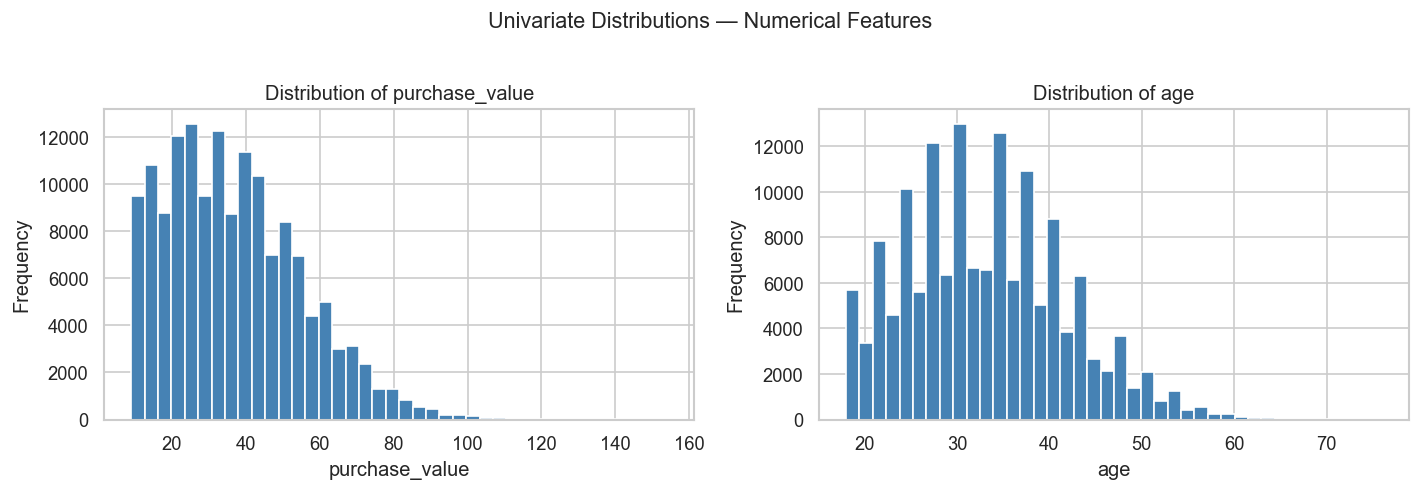

In [ ]:
# Numerical features
num_cols = ['purchase_value', 'age']

fig, axes = plt.subplots(1, len(num_cols), figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    fraud_df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Univariate Distributions — Numerical Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

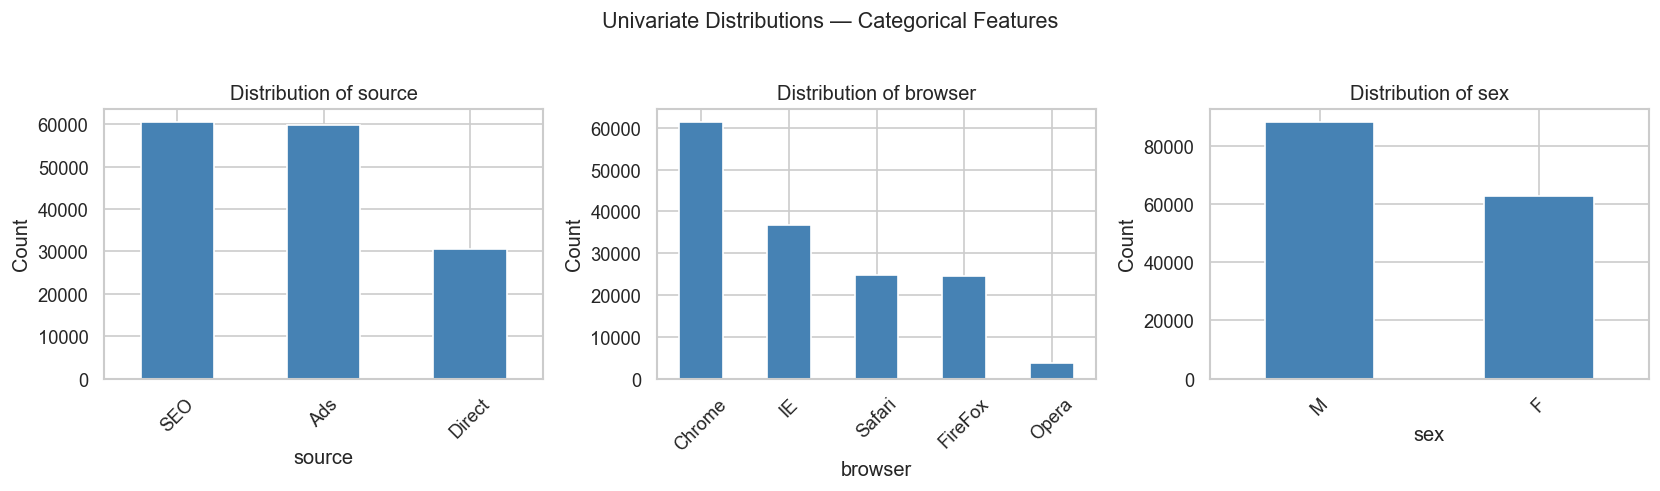

In [ ]:
# Categorical features
cat_cols = ['source', 'browser', 'sex']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    fraud_df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Univariate Distributions — Categorical Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Bivariate Analysis — Feature vs. Fraud Label

Compare feature distributions across the two classes (legitimate vs. fraud)
and calculate fraud rates per category to identify which features carry
discriminative signal.

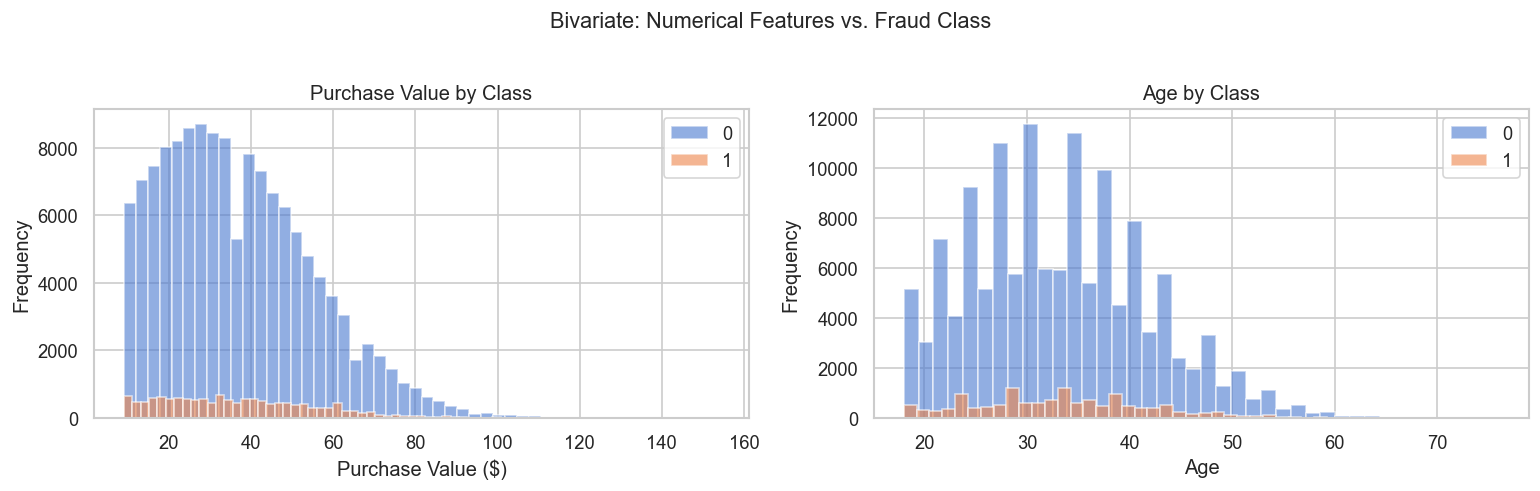

In [ ]:
# Purchase value and age by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fraud_df.groupby('class')['purchase_value'].plot(
    kind='hist', bins=50, alpha=0.6, ax=axes[0], legend=True
)
axes[0].set_title('Purchase Value by Class')
axes[0].set_xlabel('Purchase Value ($)')

fraud_df.groupby('class')['age'].plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1], legend=True
)
axes[1].set_title('Age by Class')
axes[1].set_xlabel('Age')

plt.suptitle('Bivariate: Numerical Features vs. Fraud Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

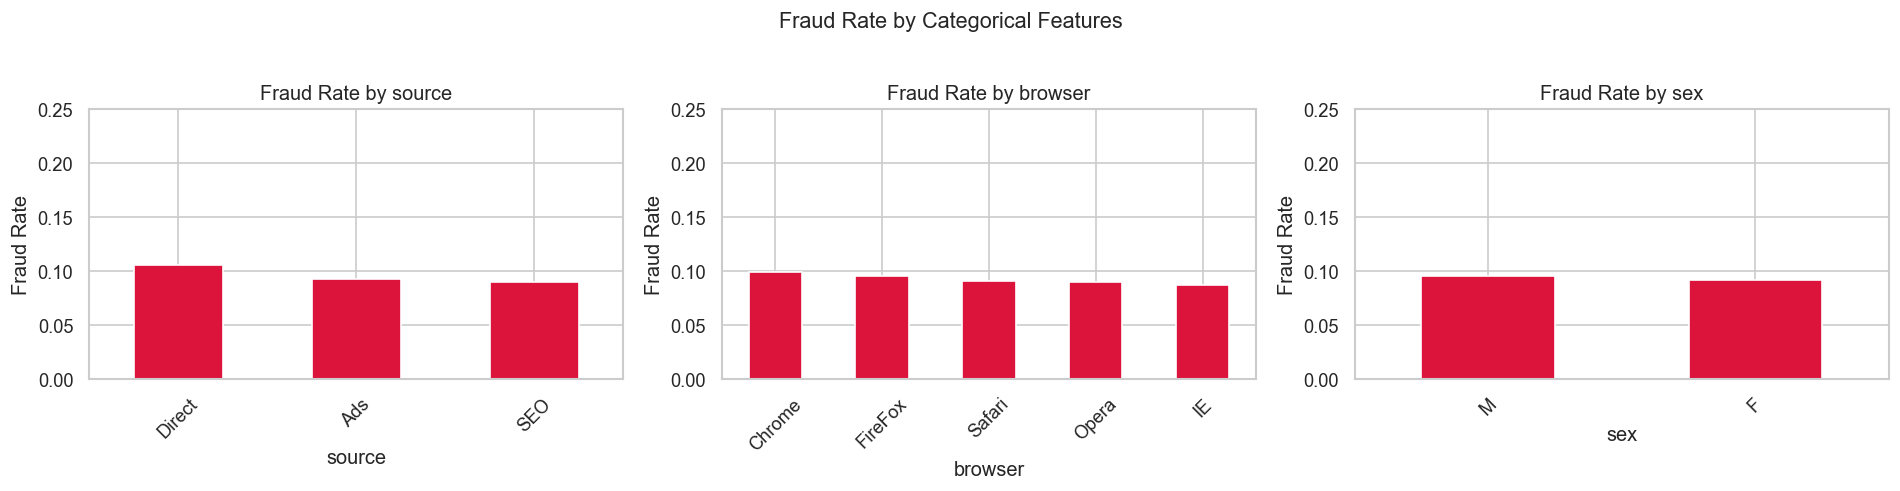

In [ ]:
# Fraud rate by categorical features
cat_cols = ['source', 'browser', 'sex']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    fraud_rate = fraud_df.groupby(col)['class'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=ax, color='crimson', edgecolor='white')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 0.25)
plt.suptitle('Fraud Rate by Categorical Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Class Imbalance Analysis

Fraud detection datasets are inherently imbalanced — fraudulent transactions
are a small minority. A naive classifier that always predicts *legitimate* can
appear highly accurate while missing every fraud case entirely.

This section quantifies the imbalance with counts, percentages, and an
imbalance ratio, then visualizes it. These numbers directly motivate our
choice of resampling strategy in the feature engineering notebook.

Class Distribution:
        count  percentage
class                    
0      136961       90.64
1       14151        9.36

Imbalance ratio — Legit:Fraud = 136961:14151 (9:1)


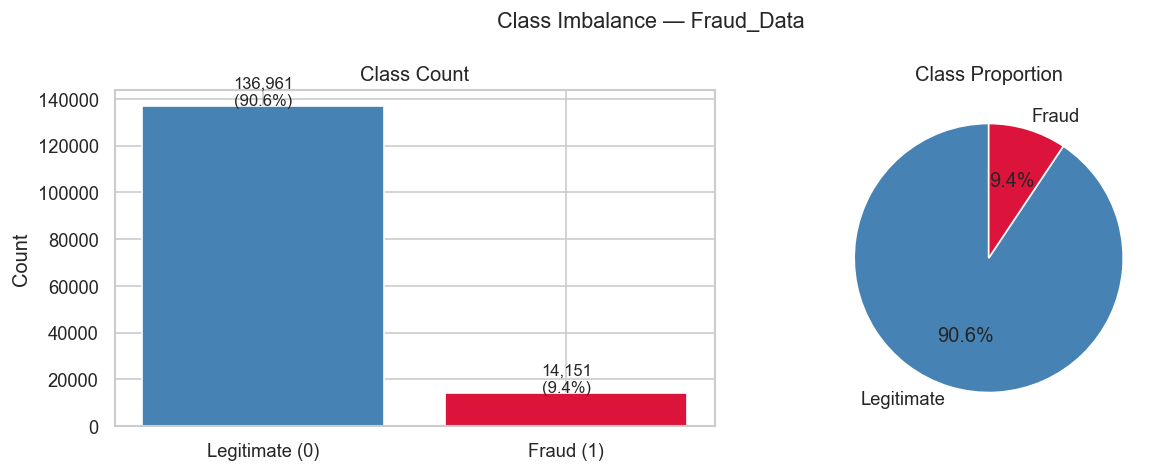

In [ ]:
class_counts = fraud_df['class'].value_counts()
class_pct = fraud_df['class'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(pd.DataFrame({'count': class_counts, 'percentage': class_pct.round(2)}))
print(f'\nImbalance ratio — Legit:Fraud = {class_counts[0]}:{class_counts[1]} '
      f'({class_counts[0] // class_counts[1]}:1)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
             color=['steelblue', 'crimson'], edgecolor='white')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({class_pct.values[i]:.1f}%)',
                 ha='center', fontsize=10)
axes[0].set_title('Class Count')
axes[0].set_ylabel('Count')

axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
             colors=['steelblue', 'crimson'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion')

plt.suptitle('Class Imbalance — Fraud_Data', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Geolocation Integration

IP addresses carry geographic fraud signals — certain countries or regions
may show higher fraud rates due to weaker fraud controls or known fraud rings.

**Approach:**
1. Convert dotted-decimal IP addresses to 64-bit integers for numeric comparison.
2. Sort the IP range table by `lower_bound` and use `numpy.searchsorted` for an
   O(log n) range lookup — far faster than a row-by-row merge on a 138k-row table.
3. Attach the resulting `country` column to the fraud dataset.
4. Analyze fraud rates by country (minimum 50 transactions for reliability).

In [ ]:
def ip_to_int(ip: str) -> float:
    """
    Convert a dotted-decimal or float IP address string to a 64-bit integer.
    Returns NaN if conversion fails.
    """
    try:
        parts = str(ip).split('.')
        if len(parts) == 4:
            return (
                int(parts[0]) * 256**3
                + int(parts[1]) * 256**2
                + int(parts[2]) * 256
                + int(parts[3])
            )
        return int(float(ip))  # handle IPs stored as floats
    except (ValueError, AttributeError):
        return np.nan


try:
    fraud_df['ip_int'] = fraud_df['ip_address'].apply(ip_to_int)
    ip_df['lower_int'] = ip_df['lower_bound_ip_address'].apply(ip_to_int)
    ip_df['upper_int'] = ip_df['upper_bound_ip_address'].apply(ip_to_int)
    logger.info('IP addresses converted to integers.')
except Exception as e:
    logger.error(f'IP conversion failed: {e}')
    raise

2026-06-07 19:07:57,569 — INFO — IP addresses converted to integers.


In [ ]:
def find_country(ip_int: float, lower_bounds: np.ndarray,
                  upper_bounds: np.ndarray, countries: np.ndarray) -> str:
    """
    Binary-search the sorted IP range table to find a country for a given IP integer.
    Returns 'Unknown' if no range matches.
    """
    if np.isnan(ip_int):
        return 'Unknown'
    try:
        idx = np.searchsorted(lower_bounds, ip_int, side='right') - 1
        if idx >= 0 and ip_int <= upper_bounds[idx]:
            return countries[idx]
        return 'Unknown'
    except Exception:
        return 'Unknown'


try:
    ip_df_sorted = ip_df.sort_values('lower_int').reset_index(drop=True)
    lower_arr = ip_df_sorted['lower_int'].values
    upper_arr = ip_df_sorted['upper_int'].values
    country_arr = ip_df_sorted['country'].values

    fraud_df['country'] = fraud_df['ip_int'].apply(
        lambda x: find_country(x, lower_arr, upper_arr, country_arr)
    )
    coverage = (fraud_df['country'] != 'Unknown').mean() * 100
    logger.info(f'Geolocation coverage: {coverage:.1f}%')
except Exception as e:
    logger.error(f'Geolocation merge failed: {e}')
    raise

2026-06-07 19:08:09,947 — INFO — Geolocation coverage: 85.5%


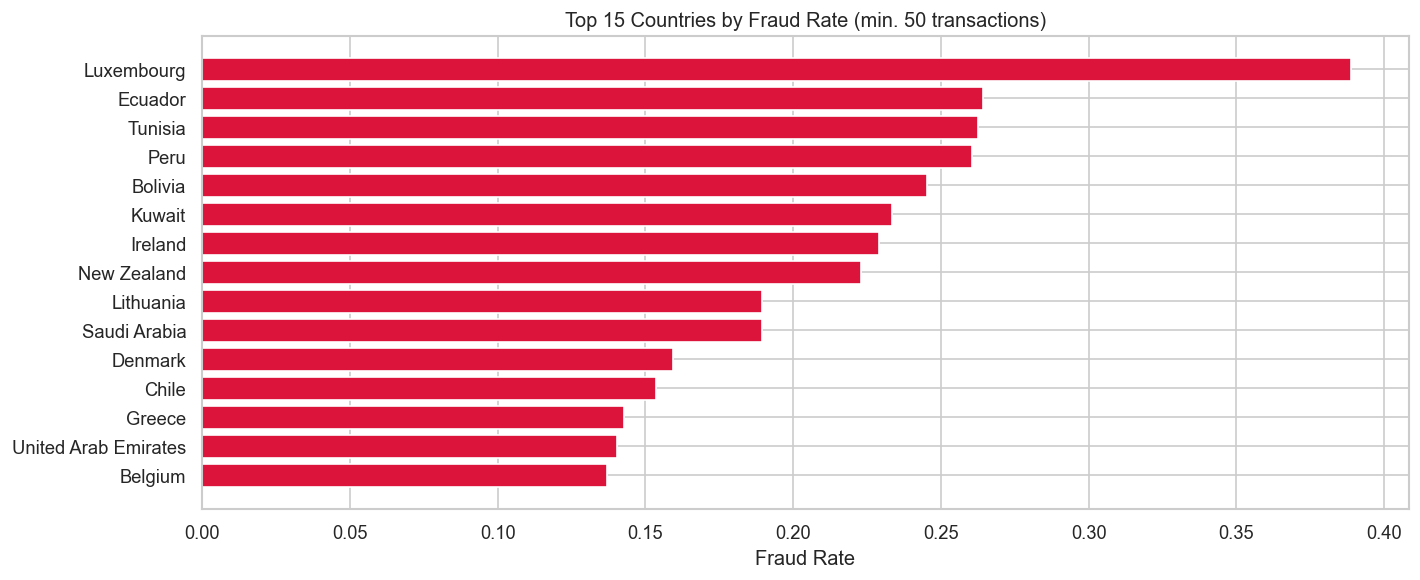

                      total  fraud  fraud_rate
country                                       
Luxembourg               72     28    0.388889
Ecuador                 106     28    0.264151
Tunisia                 118     31    0.262712
Peru                    119     31    0.260504
Bolivia                  53     13    0.245283
Kuwait                   90     21    0.233333
Ireland                 240     55    0.229167
New Zealand             278     62    0.223022
Lithuania                95     18    0.189474
Saudi Arabia            264     50    0.189394
Denmark                 490     78    0.159184
Chile                   417     64    0.153477
Greece                  231     33    0.142857
United Arab Emirates    114     16    0.140351
Belgium                 409     56    0.136919


In [ ]:
# Fraud rate by country — top 15
country_fraud = (
    fraud_df.groupby('country')
    .agg(total=('class', 'count'), fraud=('class', 'sum'))
    .assign(fraud_rate=lambda d: d['fraud'] / d['total'])
    .query('total >= 50')
    .sort_values('fraud_rate', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(country_fraud.index, country_fraud['fraud_rate'],
        color='crimson', edgecolor='white')
ax.set_xlabel('Fraud Rate')
ax.set_title('Top 15 Countries by Fraud Rate (min. 50 transactions)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(country_fraud)

## 7. Save Cleaned Data

Persist the cleaned and geolocation-enriched DataFrame to `data/processed/`
so the feature engineering notebook can pick up from this checkpoint without
re-running the full EDA pipeline.

In [28]:
import os
import joblib

try:
    os.makedirs(PROCESSED_DIR, exist_ok=True)

    # Save cleaned full dataset
    fraud_df.to_csv(PROCESSED_DIR + 'fraud_data_clean.csv', index=False)

    # Save train/test splits
    X_train_res.to_csv(PROCESSED_DIR + 'fraud_X_train.csv', index=False)
    X_test.to_csv(PROCESSED_DIR + 'fraud_X_test.csv', index=False)
    pd.Series(y_train_res).to_csv(PROCESSED_DIR + 'fraud_y_train.csv', index=False)
    y_test.to_csv(PROCESSED_DIR + 'fraud_y_test.csv', index=False)

    # Save scaler for reuse in modeling
    joblib.dump(scaler, '../models/fraud_scaler.pkl')

    logger.info('All processed splits saved to data/processed/')
    logger.info(f'X_train (resampled): {X_train_res.shape}')
    logger.info(f'X_test:              {X_test.shape}')
except Exception as e:
    logger.error(f'Failed to save processed data: {e}')
    raise

2026-06-07 19:56:38,881 — INFO — All processed splits saved to data/processed/
2026-06-07 19:56:38,883 — INFO — X_train (resampled): (219136, 12)
2026-06-07 19:56:38,885 — INFO — X_test:              (30223, 12)
